# Loading Data

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


c:\Users\Jaeden Capinig\Documents\DPP-Projekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "zkskhurram/lung-cancer-clinical-dataset-20152025" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

100%|██████████| 55.2k/55.2k [00:00<00:00, 895kB/s]

Extracting files...
Loading dataset from C:\Users\Jaeden Capinig\.cache\kagglehub\datasets\zkskhurram\lung-cancer-clinical-dataset-20152025\versions\1 to ../data/raw\lung-cancer-clinical-dataset-20152025
Moving file: C:\Users\Jaeden Capinig\.cache\kagglehub\datasets\zkskhurram\lung-cancer-clinical-dataset-20152025\versions\1\dataset_metadata.json to c:\Users\Jaeden Capinig\Documents\DPP-Projekt\notebooks\../data/raw\lung-cancer-clinical-dataset-20152025
Moving file: C:\Users\Jaeden Capinig\.cache\kagglehub\datasets\zkskhurram\lung-cancer-clinical-dataset-20152025\versions\1\lung_cancer_dataset.csv to c:\Users\Jaeden Capinig\Documents\DPP-Projekt\notebooks\../data/raw\lung-cancer-clinical-dataset-20152025
Files moved to '../data/raw\lung-cancer-clinical-dataset-20152025' directory.


In [3]:
files

['dataset_metadata.json', 'lung_cancer_dataset.csv']

# EDA

In [5]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[1]]))
df.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,...,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,Female,Current Smoker,28,28,...,No,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,2020,2020-12-09,Americas,Mexico,71,Male,Former Smoker,5,34,...,No,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2016,2016-04-05,Western Pacific,Japan,53,Female,Never Smoked,0,0,...,No,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,LC-0004,2017,2017-11-24,Western Pacific,Singapore,55,Male,Current Smoker,21,34,...,No,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2023,2023-02-19,Western Pacific,Malaysia,54,Male,Never Smoked,0,0,...,No,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


## Understanding the data

In [6]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(1500, 41)

'Description'

,count,mean,std,min,25%,50%,75%,max
Diagnosis_Year,1500.0,2020.63,3.10,2015.0,2018.0,2021.00,2023.0,2025.0
Age,1500.0,60.66,10.30,30.0,53.0,60.00,68.0,89.0
Cigarettes_Per_Day,1500.0,7.40,11.80,0.0,0.0,0.00,14.0,56.0
Years_Smoking,1500.0,8.21,12.78,0.0,0.0,0.00,17.0,59.0
BMI,1500.0,26.54,3.98,16.0,23.8,26.45,29.4,40.0
Tumor_Size_cm,1500.0,4.59,2.39,0.5,2.6,4.40,6.2,12.9
Survival_Months,1500.0,31.15,23.27,1.0,11.0,26.00,48.0,109.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
Patient_ID,object,0,1500,"[LC-0858, LC-1267, LC-0491]"
Diagnosis_Year,int64,0,11,"[2023, 2021, 2019]"
Diagnosis_Date,object,0,1222,"[2023-10-15, 2022-10-22, 2019-12-03]"
WHO_Region,object,0,6,"[Western Pacific, Europe, Western Pacific]"
Country,object,0,60,"[Myanmar, Maldives, Netherlands]"
Age,int64,0,57,"[59, 65, 68]"
Gender,object,0,2,"[Female, Male, Male]"
Smoking_Status,object,0,3,"[Never Smoked, Never Smoked, Never Smoked]"
Cigarettes_Per_Day,int64,0,47,"[0, 0, 0]"
Years_Smoking,int64,0,52,"[0, 0, 32]"


## Checking Correlations

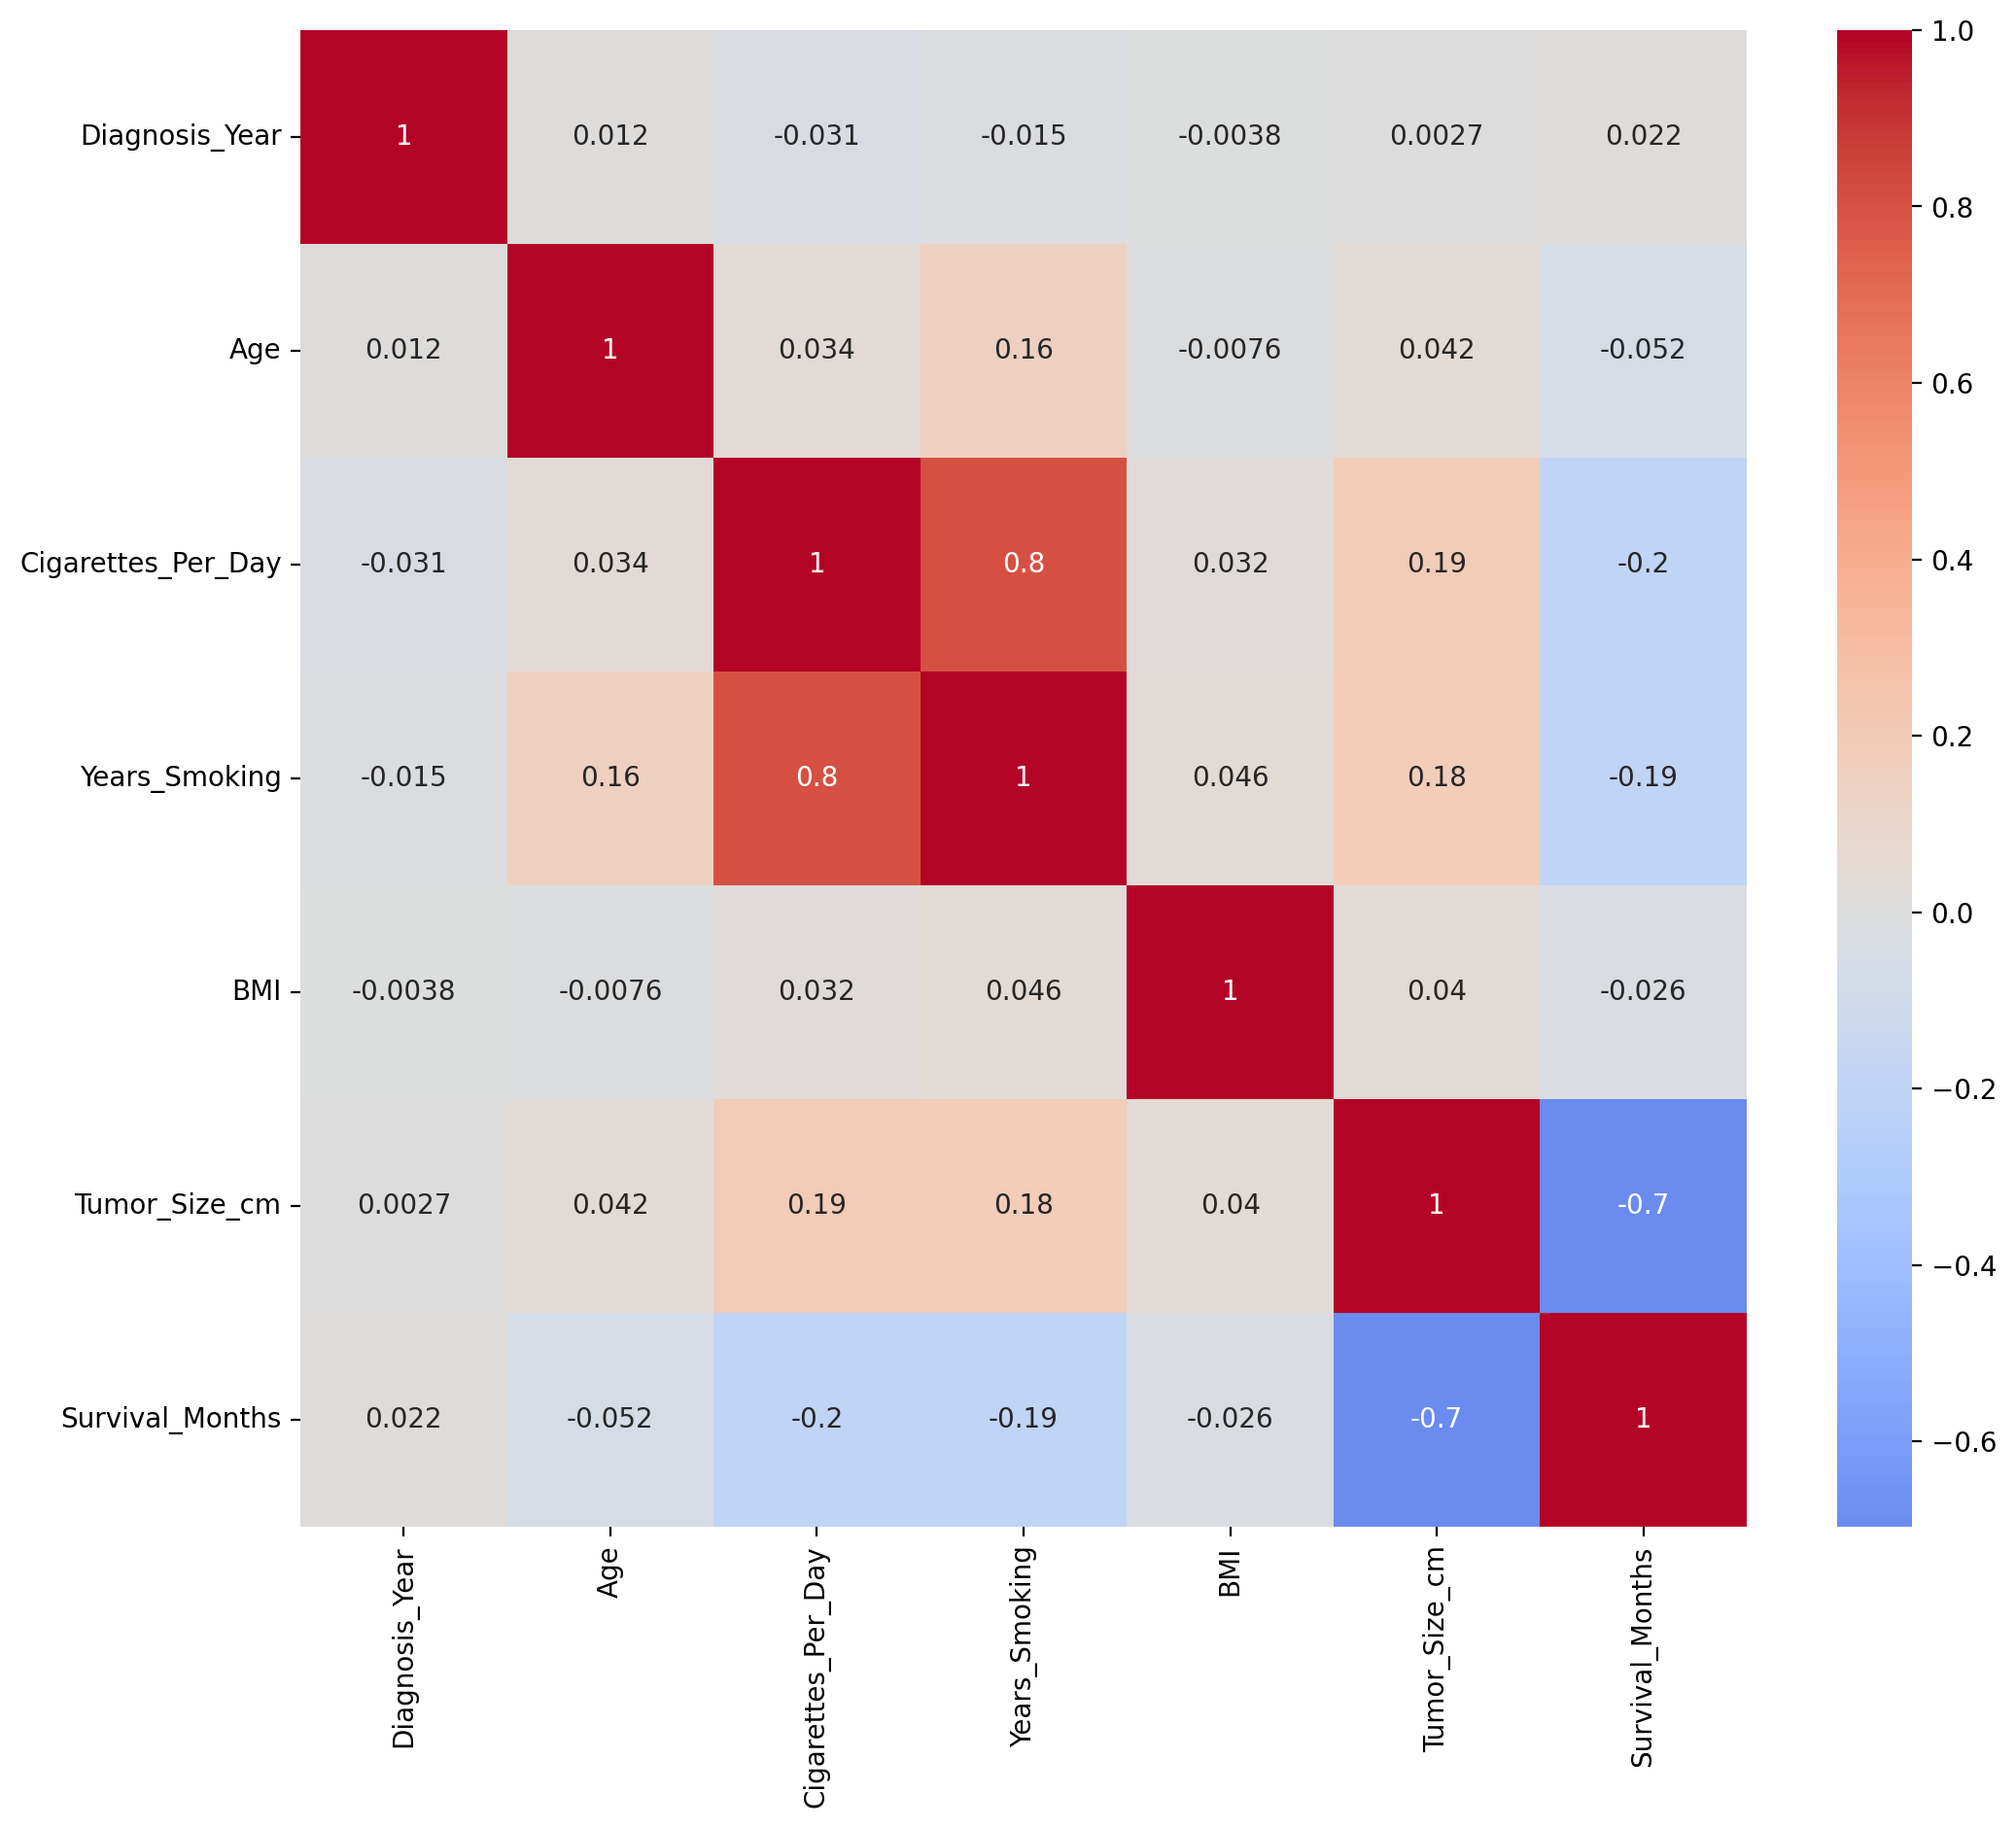

In [7]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

## Detecting outliers

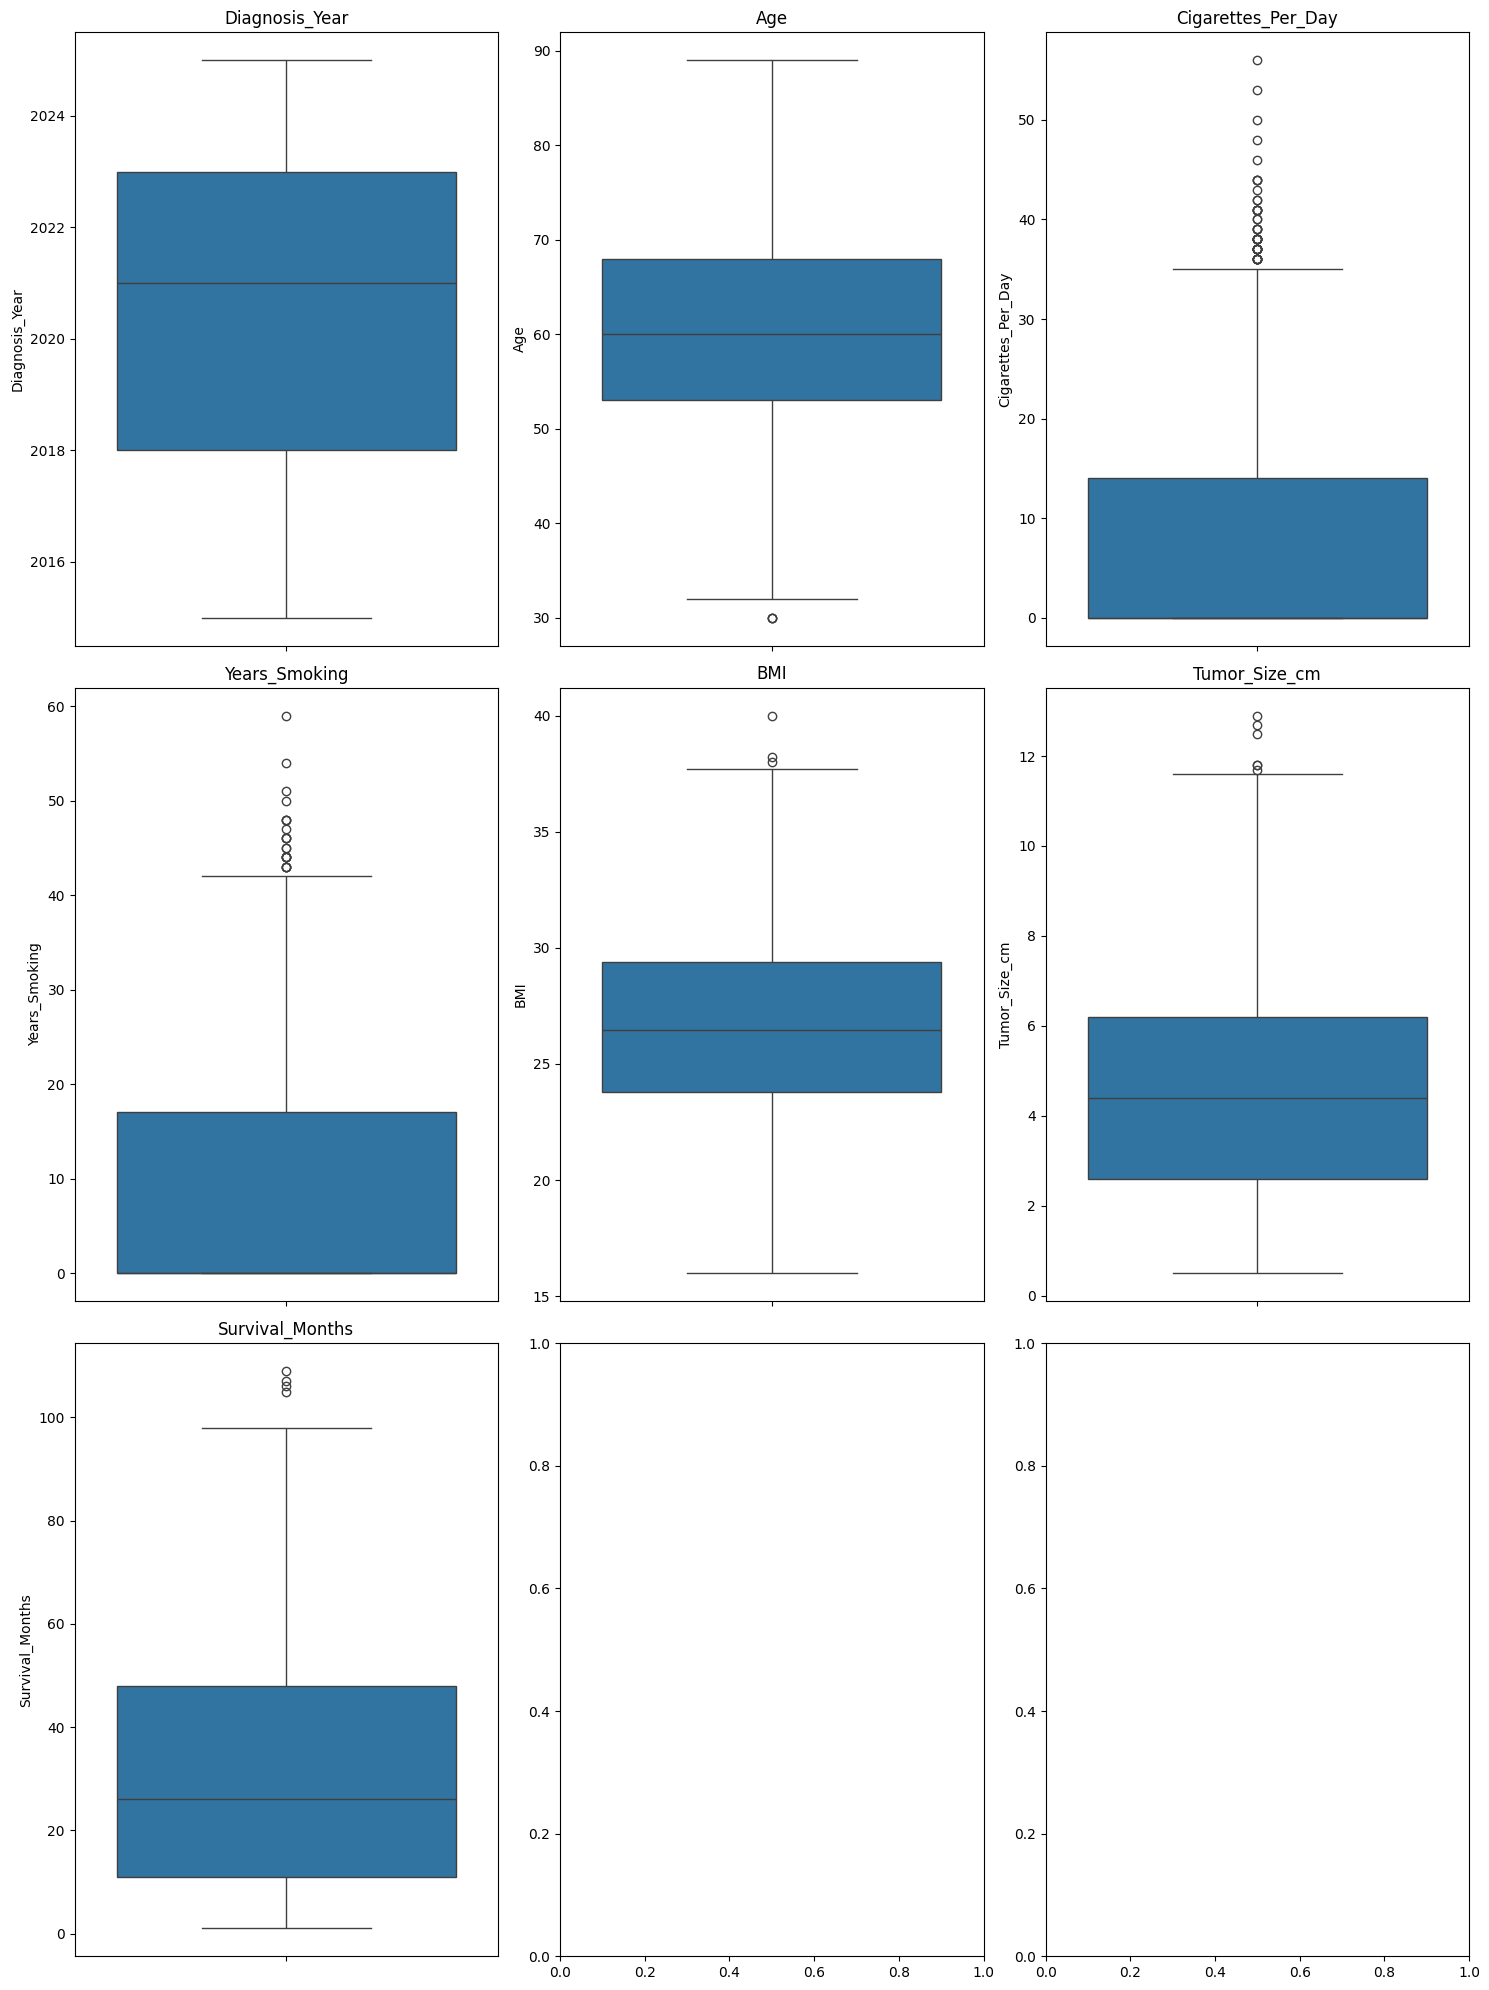

In [10]:
# Get numerical columns
num_cols = df.select_dtypes(include='number').columns

# Boxplots to visualise outliers
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [11]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers")

Age: 3 outliers
Cigarettes_Per_Day: 48 outliers
Years_Smoking: 22 outliers
BMI: 3 outliers
Tumor_Size_cm: 6 outliers
Survival_Months: 4 outliers
